In [1]:
from typing import TypedDict , List 
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    values : List[int]
    name : str 
    result : str 
    

In [9]:
def process_values(state : AgentState) -> AgentState:
    """This function handles multiple different inputs"""
    print("Before processing : "+str(state))
    state['result'] = f"Hi there {state['name']} , the sum of your values is {sum(state['values'])}"
    print("After processing : "+str(state))
    return state 

In [10]:
graph = StateGraph(AgentState)

graph.add_node("processor" , process_values)

graph.set_entry_point("processor")

graph.set_finish_point("processor")

app = graph.compile()#!!!make sure to store the compiled graph in a variable 


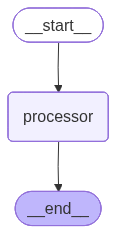

In [11]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
answers = app.invoke({"values" : [1,2,3,4,5] , "name" : "Zaid"})

Before processing : {'values': [1, 2, 3, 4, 5], 'name': 'Zaid'}
After processing : {'values': [1, 2, 3, 4, 5], 'name': 'Zaid', 'result': 'Hi there Zaid , the sum of your values is 15'}


In [8]:
print(answers)

{'values': [1, 2, 3, 4, 5], 'name': 'Zaid', 'result': 'Hi there Zaid , the sum of your values is 15'}


In [14]:
import math 
class state_operation(TypedDict):
    name : str 
    list : List[int]
    operation : str 
    result : str 

def process(state : state_operation) -> state_operation:
    if state['operation'] == 'sum':
        state['result'] = f"The sum of the list is {sum(state['list'])}"
    elif state['operation'] == 'multiply':
        state['result'] = f"The product of the list is {math.prod(state['list'])}"
    return state 
    

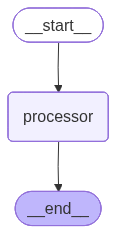

In [16]:
graph = StateGraph(state_operation)
graph.add_node("processor" , process)
graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
app.invoke({"list" : [1,2,3,4,5] , "operation" : "sum"})

{'list': [1, 2, 3, 4, 5],
 'operation': 'sum',
 'result': 'The sum of the list is 15'}